### Setup Environment

In [12]:
# #@title Install Dependencies
# %%capture
# pip install pytorch-lightning torchmetrics

import sys

sys.path.append("/home/pat/projects/pytorch-receptive-field")

In [535]:
#@title Import Dependencies

import os

import random


from datetime import datetime

from matplotlib import pyplot as plt

import numpy as np

from tqdm import tqdm
# from skimage import io
from PIL import Image
import matplotlib as mpl

import pandas as pd


import torch

from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Subset

from torchvision import transforms as T
from torchvision.datasets import MNIST, FashionMNIST

import torchmetrics
import pytorch_lightning as pl
from sklearn.metrics import ConfusionMatrixDisplay

In [536]:
#@title Variables

DEVICE="cpu"
NUM_CLASSES = 10
BATCH_SIZE = 64
NUM_WORKERS = 2
SEED = 1

MAIN_TRANSFORM = T.ToTensor()

# SEEN_CLASSES = list(range(5))
# UNSEEN_CLASSES = list(set(range(10)).difference(SEEN_CLASSES))

# SEEN_CLASSES, UNSEEN_CLASSES

ALL_CLASSES = list(range(10))

TRAINING_SAMPLES_BASIS = 600

# Construct Subset

In [537]:
def get_loaders():
    data_class = FashionMNIST
    train_ds = data_class(
        root="./datasets", train=True, transform=MAIN_TRANSFORM, download=True
    )

    val_ds = data_class(
        root="./datasets", train=False, transform=MAIN_TRANSFORM, download=True
    )

    np.random.seed(1)

    train_ds_small = Subset(
        train_ds,
        indices=np.random.permutation(train_ds.data.shape[0])[:TRAINING_SAMPLES_BASIS]
    )

    return DataLoader(train_ds, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE, shuffle=True), \
        DataLoader(val_ds, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE, shuffle=False), \
        DataLoader(train_ds_small, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE, shuffle=False)

train_loader, val_loader, train_small_loader = get_loaders()

In [333]:
class Lenet5(nn.Module):
    def __init__(self, input_channels=1, num_classes=10):
        super().__init__()

        
        self.layer1 = nn.Sequential(
            nn.Conv2d(input_channels, 6, kernel_size=5, padding=2, padding_mode="replicate"),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2)
        )

        
        self.layer2 = nn.Sequential(
            nn.Conv2d(6,  16, kernel_size=5),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2)
        )
        
        self.layer3 = nn.Sequential(
            nn.Conv2d(16,  120, kernel_size=5),
            nn.ReLU(),
        )


        self.lin1 = nn.Linear(120, 84)
        self.act4 = nn.ReLU()


        self.lin2 = nn.Linear(84, num_classes)


    def forward(self, x):
        x = self.layer1(x)
 

        x = self.layer2(x)
    
        x = self.layer3(x)
    

        x = torch.flatten(x, start_dim=1)

        x = self.act4(self.lin1(x))
        x = self.lin2(x)

        return x

    def __str__(self):
        return "Lenet5"

class ModelWrapper(pl.LightningModule):
    def __init__(self, model):
        super().__init__()

        self.model = model

        self.valid_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10)


    def forward(self, x):
        embedding = self.model(x)
        return embedding

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        return optimizer

    def training_step(self, train_batch, batch_idx):
        x, y = train_batch

        yh = self.model(x)

        loss = F.cross_entropy(yh, y)

        return loss

    def validation_step(self, val_batch, batch_idx):
        x, y = val_batch

        logits = self.model(x)
        self.valid_acc.update(logits, y)

    def on_validation_epoch_end(self):
        acc = self.valid_acc.compute()
        print(f"acc={acc}")
        self.log('valid_acc_epoch', self.valid_acc.compute())
        self.valid_acc.reset()

def train(model, train_loader, val_loader, epochs=5):

    pl.seed_everything(SEED)

    start_time = datetime.now()

    trainer = pl.Trainer(accelerator=DEVICE, max_epochs=epochs)
    trainer.fit(ModelWrapper(model), train_loader, val_loader)

    print("Time Took:", (datetime.now() - start_time) / 60, "mins")

    return model


model = Lenet5()
train(model, train_loader, val_loader, epochs=10)

Global seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name      | Type               | Params
-------------------------------------------------
0 | model     | Lenet5             | 61.7 K
1 | valid_acc | MulticlassAccuracy | 0     
-------------------------------------------------
61.7 K    Trainable params
0         Non-trainable params
61.7 K    Total params
0.247     Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:430: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 8 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


acc=0.078125


/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:430: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 8 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


...

acc=0.8745999932289124


Validation: 0it [00:00, ?it/s]

acc=0.8831999897956848


Validation: 0it [00:00, ?it/s]

acc=0.8792999982833862


In [358]:
from torch_receptive_field import receptive_field

In [359]:
receptive_field(
    model.layer1,
    (1, 28, 28)
)

------------------------------------------------------------------------------
        Layer (type)    map size      start       jump receptive_field 
        0               [28, 28]        0.5        1.0             1.0 
        1               [28, 28]        0.5        1.0             5.0 
        2               [28, 28]        0.5        1.0             5.0 
        3               [14, 14]        1.0        2.0             6.0 


OrderedDict([('0',
              OrderedDict([('j', 1.0),
                           ('r', 1.0),
                           ('start', 0.5),
                           ('conv_stage', True),
                           ('output_shape', [-1, 1, 28, 28])])),
             ('1',
              OrderedDict([('j', 1.0),
                           ('r', 5.0),
                           ('start', 0.5),
                           ('input_shape', [-1, 1, 28, 28]),
                           ('output_shape', [-1, 6, 28, 28])])),
             ('2',
              OrderedDict([('j', 1.0),
                           ('r', 5.0),
                           ('start', 0.5),
                           ('input_shape', [-1, 6, 28, 28]),
                           ('output_shape', [-1, 6, 28, 28])])),
             ('3',
              OrderedDict([('j', 2.0),
                           ('r', 6.0),
                           ('start', 1.0),
                           ('input_shape', [-1, 6, 28, 28]),
             

In [360]:
receptive_field(
    model.layer2,
    (6, 14, 14)
)

------------------------------------------------------------------------------
        Layer (type)    map size      start       jump receptive_field 
        0               [14, 14]        0.5        1.0             1.0 
        1               [10, 10]        2.5        1.0             5.0 
        2               [10, 10]        2.5        1.0             5.0 
        3                 [5, 5]        3.0        2.0             6.0 


OrderedDict([('0',
              OrderedDict([('j', 1.0),
                           ('r', 1.0),
                           ('start', 0.5),
                           ('conv_stage', True),
                           ('output_shape', [-1, 6, 14, 14])])),
             ('1',
              OrderedDict([('j', 1.0),
                           ('r', 5.0),
                           ('start', 2.5),
                           ('input_shape', [-1, 6, 14, 14]),
                           ('output_shape', [-1, 16, 10, 10])])),
             ('2',
              OrderedDict([('j', 1.0),
                           ('r', 5.0),
                           ('start', 2.5),
                           ('input_shape', [-1, 16, 10, 10]),
                           ('output_shape', [-1, 16, 10, 10])])),
             ('3',
              OrderedDict([('j', 2.0),
                           ('r', 6.0),
                           ('start', 3.0),
                           ('input_shape', [-1, 16, 10, 10]),
         

In [386]:
receptive_field(
    nn.Sequential(
        model.layer2,
        model.layer3
    ),
    (6, 14, 14)
)

------------------------------------------------------------------------------
        Layer (type)    map size      start       jump receptive_field 
        0               [14, 14]        0.5        1.0             1.0 
        1               [10, 10]        2.5        1.0             5.0 
        2               [10, 10]        2.5        1.0             5.0 
        3                 [5, 5]        3.0        2.0             6.0 
        4                 [1, 1]        7.0        2.0            14.0 
        5                 [1, 1]        7.0        2.0            14.0 


OrderedDict([('0',
              OrderedDict([('j', 1.0),
                           ('r', 1.0),
                           ('start', 0.5),
                           ('conv_stage', True),
                           ('output_shape', [-1, 6, 14, 14])])),
             ('1',
              OrderedDict([('j', 1.0),
                           ('r', 5.0),
                           ('start', 2.5),
                           ('input_shape', [-1, 6, 14, 14]),
                           ('output_shape', [-1, 16, 10, 10])])),
             ('2',
              OrderedDict([('j', 1.0),
                           ('r', 5.0),
                           ('start', 2.5),
                           ('input_shape', [-1, 16, 10, 10]),
                           ('output_shape', [-1, 16, 10, 10])])),
             ('3',
              OrderedDict([('j', 2.0),
                           ('r', 6.0),
                           ('start', 3.0),
                           ('input_shape', [-1, 16, 10, 10]),
         

In [362]:
receptive_field(
    model.layer3,
    (16, 5, 5)
)

------------------------------------------------------------------------------
        Layer (type)    map size      start       jump receptive_field 
        0                 [5, 5]        0.5        1.0             1.0 
        1                 [1, 1]        2.5        1.0             5.0 
        2                 [1, 1]        2.5        1.0             5.0 


OrderedDict([('0',
              OrderedDict([('j', 1.0),
                           ('r', 1.0),
                           ('start', 0.5),
                           ('conv_stage', True),
                           ('output_shape', [-1, 16, 5, 5])])),
             ('1',
              OrderedDict([('j', 1.0),
                           ('r', 5.0),
                           ('start', 2.5),
                           ('input_shape', [-1, 16, 5, 5]),
                           ('output_shape', [-1, 120, 1, 1])])),
             ('2',
              OrderedDict([('j', 1.0),
                           ('r', 5.0),
                           ('start', 2.5),
                           ('input_shape', [-1, 120, 1, 1]),
                           ('output_shape', [-1, 120, 1, 1])])),
             ('input_size', (16, 5, 5))])

(10000,) (10000,)


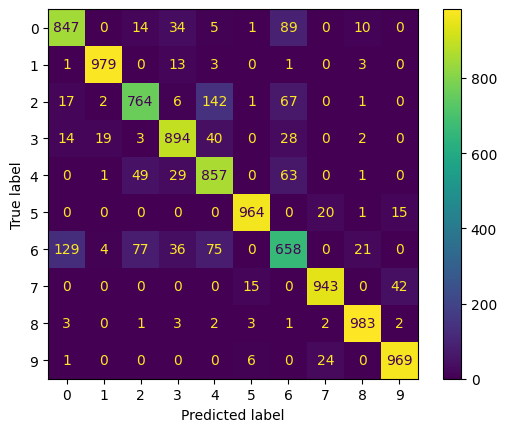

In [363]:
from sklearn.metrics import ConfusionMatrixDisplay

@torch.no_grad()
def ano():


    arr_y = []

    arr_yh = []

    for x, y in val_loader:

        logits = model(x)
        yh = torch.argmax(logits, dim=1)

        arr_yh.append(yh.detach().cpu().numpy())
        arr_y.append(y.detach().cpu().numpy())


    arr_yh = np.hstack(arr_yh)
    arr_y = np.hstack(arr_y)
    print(arr_yh.shape, arr_y.shape)

    ConfusionMatrixDisplay.from_predictions(
        arr_y,
        arr_yh
    )

ano()


# Extract Activation and Projection

In [551]:
from tqdm import tqdm
import os


def attach_act_forward_hook(module):

    def fh(mod, input, output):

        assert isinstance(output, torch.Tensor)

        setattr(mod, "__output", output)
        output.retain_grad()

    hook = module.register_forward_hook(fh)

    return module, hook

def extract_features(model, layer,  output_dir="./tmp", seed=1, verbose=False, is_saved=True):

    np.random.seed(seed)
    
    assert layer == "layer3"


    if verbose:

        print(f"Extracting activation from {layer}")

        
    crop = T.RandomCrop(14)
    
    arr_input = []
    arr_output = []

    try:
        module, hook = attach_act_forward_hook(getattr(model, layer))
        for bix, batch in enumerate(train_small_loader):
            x, y = batch
            x = model.layer1(x)
            
            x = crop(x).detach()
            y = model.layer3(model.layer2(x))
            arr_output.append(y.flatten(start_dim=1).detach().cpu().numpy())
            arr_input.append(x.detach().cpu().numpy())

    finally:
        hook.remove()

    arr_output = np.vstack(arr_output)
    arr_input = np.vstack(arr_input)
    print("arr_input.shape", arr_input.shape)


    if is_saved:
        output_dir = f"./output/{layer}"
        os.makedirs(output_dir, exist_ok=True)

        mean = np.mean(arr_output, axis=0)

        cov = np.cov(arr_output.T)

        _, eigvecs = np.linalg.eigh(cov)

        eigvecs = eigvecs[:, ::-1]

        np.save(f"{output_dir}/mean.npy", mean)
        np.save(f"{output_dir}/eigvecs.npy", eigvecs)
        
        np.save(f"{output_dir}/input.npy", arr_input)
        np.save(f"{output_dir}/output.npy", arr_output)

    return arr_output


extract_features(model, "layer3")

arr_input.shape (600, 6, 14, 14)


array([[0.8514554 , 0.        , 0.54612696, ..., 0.        , 2.6184726 ,
        0.        ],
       [2.6570694 , 0.        , 0.        , ..., 4.193534  , 4.051025  ,
        0.        ],
       [0.        , 0.        , 1.4898818 , ..., 2.352049  , 0.        ,
        0.        ],
       ...,
       [2.8283706 , 0.        , 0.        , ..., 3.220124  , 4.2567105 ,
        0.        ],
       [2.2404935 , 0.        , 0.        , ..., 1.7723383 , 5.1365213 ,
        0.        ],
       [0.4625972 , 0.        , 0.        , ..., 0.        , 2.5306454 ,
        0.        ]], dtype=float32)

In [552]:
from torchmetrics.classification import BinaryAUROC, Accuracy

@torch.no_grad()
def compute_acc(model):
    metric = Accuracy(task="multiclass", num_classes=10)
    for x, y in val_loader:
        logits = model(x).detach().cpu()

        metric.update(logits, y)

    return float(metric.compute())

teacher_acc = compute_acc(model)

teacher_acc

0.8858000040054321

In [553]:
model

Lenet5(
  (layer1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), padding_mode=replicate)
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (layer2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (layer3): Sequential(
    (0): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
  )
  (lin1): Linear(in_features=120, out_features=84, bias=True)
  (act4): ReLU()
  (lin2): Linear(in_features=84, out_features=10, bias=True)
)

In [554]:
def attach_projected_fh_with_k(module, k, projector):
    DEVICE = "cpu"
    U, mu = projector

    

    d = U.shape[0]
    U = torch.from_numpy(U[:, :k]).float().to(DEVICE)
    
    UUT = (U @ U.T).reshape((d, d, 1, 1))
    

    mu = torch.from_numpy(mu).float().to(DEVICE).reshape((1, d, 1, 1))

    def fh(mod, input, output):

        assert isinstance(output, torch.Tensor)

        return  F.conv2d(
            output - mu,
            UUT,
        ) + mu
    
    hook = module.register_forward_hook(fh)

    return hook


def stats(layers):

    stats = []

    for layer, arr_ks in layers:
        U = np.load(f"output/{layer}/eigvecs.npy")
        mean = np.load(f"output/{layer}/mean.npy")

        module = getattr(model, layer)
        for k in arr_ks:
            try:
                hook = attach_projected_fh_with_k(module, k, (U, mean))

                acc = compute_acc(model)
                stats.append(
                    dict(
                        layer=layer,
                        acc=acc,
                        k=k
                    )
                )

            finally:
                hook.remove()


    return pd.DataFrame(stats)

df_dim_stats = stats([
    ("layer3", list(range(0, 56 // 2 + 1, 4)) +[120] ),
])
df_dim_stats

,layer,acc,k
0,layer3,0.1000,0
1,layer3,0.6287,4
2,layer3,0.8009,8
3,layer3,0.8286,12
4,layer3,0.8624,16
5,layer3,0.8704,20
6,layer3,0.8709,24
7,layer3,0.8750,28
8,layer3,0.8858,120


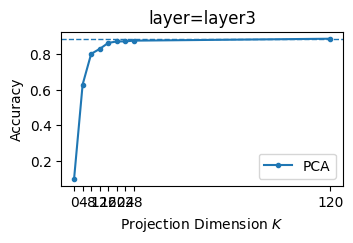

In [555]:
def ano(df):
    plt.figure(figsize=(2*4, 2))
    for lix, layer in enumerate(["layer3"]):
        _df = df[df.layer == layer]

        plt.subplot(1, 2, lix + 1)
        plt.axhline(teacher_acc, ls="--", lw=1)
        plt.plot(_df.k, _df.acc, marker=".", label="PCA")
        plt.title(f"layer={layer}")
        plt.xticks(_df.k)

        if lix == 0:
            plt.ylabel("Accuracy")
            plt.legend()



        if lix == 0:
            plt.xlabel("Projection Dimension $K$")
        else:
            plt.xlabel("Projection Dimension $K'$")
ano(df_dim_stats)

In [556]:
def get_projector(layer):
    U = np.load(f"output/{layer}/eigvecs.npy")
    mean = np.load(f"output/{layer}/mean.npy")

    return U, mean

def projection(layer, output, k):

    U, mean = get_projector(layer)
    U = U[:, :k]

    out = (output - mean) @ U
    return out

In [557]:
def prepare_data_for_svm(k):

    x_ori = np.load("./output/layer3/input.npy")
    print(x_ori.shape)
    x = x_ori.reshape(x_ori.shape[0], -1)
    y = np.load("./output/layer3/output.npy")
    y = projection("layer3", y, k=k).squeeze()

    return x_ori, x, y

x_ori, X_svm, y_svm = prepare_data_for_svm(k=60)

(600, 6, 14, 14)


In [558]:
from sklearn import svm
from sklearn.multioutput import MultiOutputRegressor

def ano():
    regr = svm.SVR()
    if y_svm.shape[1] > 1:
        regr = MultiOutputRegressor(regr)

    regr.fit(X_svm, y_svm)
    return regr

approxer = ano()

In [559]:
approxer.estimators_[0].get_params(), X_svm.var()

({'C': 1.0,
  'cache_size': 200,
  'coef0': 0.0,
  'degree': 3,
  'epsilon': 0.1,
  'gamma': 'scale',
  'kernel': 'rbf',
  'max_iter': -1,
  'shrinking': True,
  'tol': 0.001,
  'verbose': False},
 0.27923214)

In [560]:
def ano():
    
    print(
        model.layer2(model.layer1(torch.randn(10, 1, 28, 28))).shape
    )
ano()

torch.Size([10, 16, 5, 5])


In [561]:
class SVCConvLayer(nn.Module):
    
    def __init__(self, approxers):
        super().__init__()
        ntraining, d = X_svm.shape
        k = len(approxer.estimators_)
        A = np.zeros((k, ntraining))
        din = 16
        
        intercepts = np.zeros((k, ))
        
        for i in range(k):
            _est = approxer.estimators_[i]
            A[i, _est.support_] = _est.dual_coef_ 
            intercepts[i] = _est._intercept_
        
        self.A = torch.from_numpy(A).float()
        self.intercepts = torch.from_numpy(intercepts).float().reshape((1, k, 1, 1))
        
        self.gamma = 1 / (d * X_svm.var())
        self.W = torch.from_numpy(x_ori).float()
#         .reshape((ntraining, din, 14, 14))
        
        self.b = torch.linalg.norm(torch.from_numpy(X_svm).float(), dim=1) ** 2
        self.b = self.b.reshape((1, ntraining, 1, 1))
        

    
    def forward(self, x):
        
        d = x.shape[1]
        
        norm = F.conv2d(
            x ** 2,
            torch.ones(1, d, 14, 14),
            stride=3
        )
        
        out = F.conv2d(x, self.W, stride=3) 
        
        out = (2*out - norm - self.b) * self.gamma
        out = torch.exp(out)
        
        

        out = torch.einsum(
            "ijkl,tj->itkl",
            out,
            self.A
        )

        out = out + self.intercepts


        return out
    
    
_svc = SVCConvLayer(approxer)

In [562]:
def ano():
    __x = X_svm[:20, ]
    
    d = __x.shape[1]
    xnu = __x @ X_svm.T
    
    b = np.linalg.norm(X_svm, axis=1) ** 2
    gamma = 1/ (d * X_svm.var())
    
    norm = np.linalg.norm(__x, axis=1) ** 2
    
    out = (2*xnu - b - norm.reshape((-1, 1))) * (gamma)
    
    out = np.exp(out) 
    
    
    kx = out[:, approxer.estimators_[0].support_]
    print(kx.shape)
    coef = approxer.estimators_[0].dual_coef_.squeeze()
    print(coef.shape)
    
    out = kx @ coef + approxer.estimators_[0]._intercept_
    
    print(out.shape)
    return out
ano()

(20, 525)
(525,)
(20,)


array([ 2.2895018 , 14.05639205, -1.98579478, -0.74982559, -2.99473461,
       -1.53272841, -2.89968612, -0.65055951, -1.12999919, -2.2560177 ,
       -2.85971945, -1.85370222, -0.49666248,  1.80685462, -4.09391102,
       -0.16013219, -4.09203691, -0.70190515, -4.55586082,  1.15160391])

In [563]:
# dir(approxer.estimators_[0])

In [564]:
approxer.estimators_[0]._intercept_

array([1.40317245])

In [565]:
def ano():
    
    ns = len(approxer.estimators_)
    for i in range(ns):
        print(f"support {i}:", approxer.estimators_[i].n_support_)
ano()

support 0: [525]
support 1: [523]
support 2: [520]
support 3: [512]
support 4: [541]
support 5: [515]
support 6: [516]
support 7: [500]
support 8: [514]
support 9: [508]
support 10: [518]
support 11: [509]
support 12: [516]
support 13: [506]
support 14: [501]
support 15: [503]
support 16: [500]
support 17: [484]
support 18: [492]
support 19: [486]
support 20: [480]
support 21: [483]
support 22: [502]
support 23: [479]
support 24: [478]
support 25: [470]
support 26: [476]
support 27: [478]
support 28: [473]
support 29: [457]
support 30: [464]
support 31: [472]
support 32: [450]
support 33: [486]
support 34: [475]
support 35: [488]
support 36: [465]
support 37: [438]
support 38: [448]
support 39: [445]
support 40: [447]
support 41: [443]
support 42: [439]
support 43: [425]
support 44: [454]
support 45: [437]
support 46: [447]
support 47: [434]
support 48: [430]
support 49: [427]
support 50: [436]
support 51: [427]
support 52: [428]
support 53: [429]
support 54: [419]
support 55: [399]
su

In [566]:
class ApproxerWrapper(nn.Module):
    def __init__(self, approxer):
        super().__init__()
        k = len(approxer.estimators_)

        U, mean = get_projector("layer2")
        d = U.shape[0]
        self.U = torch.from_numpy(U[:, :k]).float().reshape((d, k, 1, 1))
        self.mean = torch.from_numpy(mean).float().reshape((1, d, 1, 1))
        self.svc_conv = SVCConvLayer(approxer)

    def forward(self, x):
        x = model.layer1(x)
        x = self.svc_conv(x)
        x = F.conv2d(
            x, 
            self.U
        ) + self.mean
                
        x = torch.flatten(x, start_dim=1)

        x = model.act4(model.lin1(x))
        x = model.lin2(x)

        return x


compute_acc(ApproxerWrapper(approxer))

0.8016999959945679

In [567]:
teacher_acc = compute_acc(model)

teacher_acc

0.8858000040054321

In [569]:
training_sample_ratio= TRAINING_SAMPLES_BASIS / (train_loader.dataset.data.shape[0] )

print(f"We use {training_sample_ratio*100}% of training data")

We use 1.0% of training data
